# Initial feature preprocessing

## Overview

This notebook performs the initial preprocessing steps that are shared across 
both the classification and regression modeling pipelines.

The following steps are applied:

1. **Feature engineering from date feature**

2. **Correlation analysis** 

3. **Diagnosing Missing values**

4. **Outlier analysis**

## 1. Configuration

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

company_colors = {"NVDA": "#4DB6AC", "AMD": "#BA68C8", "INTC": "#5C9BD5"}
sns.set_theme(style="ticks", font_scale=1.1)

df = pd.read_csv('datasets/final/final_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

TARGET_COLS   = ['target_direction','target_volatility_10d']
META_COLS     = ['date', 'ticker', 'company']

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Shape: (7413, 53)
Columns: ['date', 'company', 'open', 'high', 'low', 'close', 'volume', 'sma_10', 'sma_20', 'wma_10', 'rsi_14', 'macd', 'macd_signal', 'stoch_k', 'stoch_d', 'williams_r', 'roc_10', 'mom_10', 'trix', 'bb_upper', 'bb_middle', 'bb_lower', 'atr_14', 'natr', 'obv', 'ad', 'adosc', 'log_volume', 'volume_chng', 'rv_daily', 'rv_weekly', 'rv_monthly', 'target_direction', 'target_log_volatility_5d', 'FEDFUNDS', 'DGS10', 'DGS2', 'yield_spread', 'VIX', 'nasdaq_return', 'soxx_return', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'Mom', 'reddit_sentiment', 'reddit_post_count', 'reddit_comment_count', 'news_sentiment', 'news_count']


## 2. Feature engineering from date feature

Raw date values are not suitable as model inputs because treating dates as ordinary numerical values may encourage the model to learn relationships tied to specific points in time rather than underlying market dynamics, potentially reducing its ability to generalize to future observations.

To capture the cyclical nature of time, month and day-of-week are encoded using sine and cosine transformations. For a variable with period $T$, the encoding is defined as:

$$x_{\sin} = \sin\left(\frac{2\pi \cdot x}{T}\right), \quad x_{\cos} = \cos\left(\frac{2\pi \cdot x}{T}\right)$$

This maps each value onto a unit circle, preserving the cyclical structure of temporal variables. As a result, values located near cycle boundaries (e.g. December and January) are represented as neighboring points in the transformed space. Two components are required because sine alone is not injective. For example, March and September share the same sine value. Together, sine and cosine uniquely determine each position within the cycle.

The following temporal features are constructed:
- **`month_sin`, `month_cos`** — cyclical encoding of the calendar 
  month ($T = 12$), capturing seasonal patterns in market behavior
- **`dow_sin`, `dow_cos`** — cyclical encoding of the day of week 
  ($T = 5$, trading days only: Monday=0 to Friday=4), capturing 
  within-week patterns such as the Monday effect

In [9]:
# Month — period T=12
df['month_sin'] = np.sin(2 * np.pi * df['date'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['date'].dt.month / 12)

# Day of week — period T=5 (trading days: Monday=0, Friday=4)
df['dow_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofweek / 5)
df['dow_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofweek / 5)

print('Temporal features added:')
print(df[['date', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']].head(10))

Temporal features added:
        date     month_sin  month_cos   dow_sin   dow_cos
0 2016-05-31  5.000000e-01  -0.866025  0.951057  0.309017
1 2016-06-01  1.224647e-16  -1.000000  0.587785 -0.809017
2 2016-06-02  1.224647e-16  -1.000000 -0.587785 -0.809017
3 2016-06-03  1.224647e-16  -1.000000 -0.951057  0.309017
4 2016-06-06  1.224647e-16  -1.000000  0.000000  1.000000
5 2016-06-07  1.224647e-16  -1.000000  0.951057  0.309017
6 2016-06-08  1.224647e-16  -1.000000  0.587785 -0.809017
7 2016-06-09  1.224647e-16  -1.000000 -0.587785 -0.809017
8 2016-06-10  1.224647e-16  -1.000000 -0.951057  0.309017
9 2016-06-13  1.224647e-16  -1.000000  0.000000  1.000000


## 3. Correlation analysis

Since most technical indicators are derived from the same underlying stock
price series, a substantial degree of correlation between predictors is
expected. Correlation analysis was performed on the complete dataset to obtain an initial understanding of relationships between predictors and identify potentially redundant variables.

*Features exhibiting very high pairwise correlations are marked as candidates
for further inspection during the modeling stage.*

In [10]:
feature_cols = [
    col for col in df.columns
    if col not in META_COLS + TARGET_COLS
]

print(f'Number of features: {len(feature_cols)}')

Number of features: 54


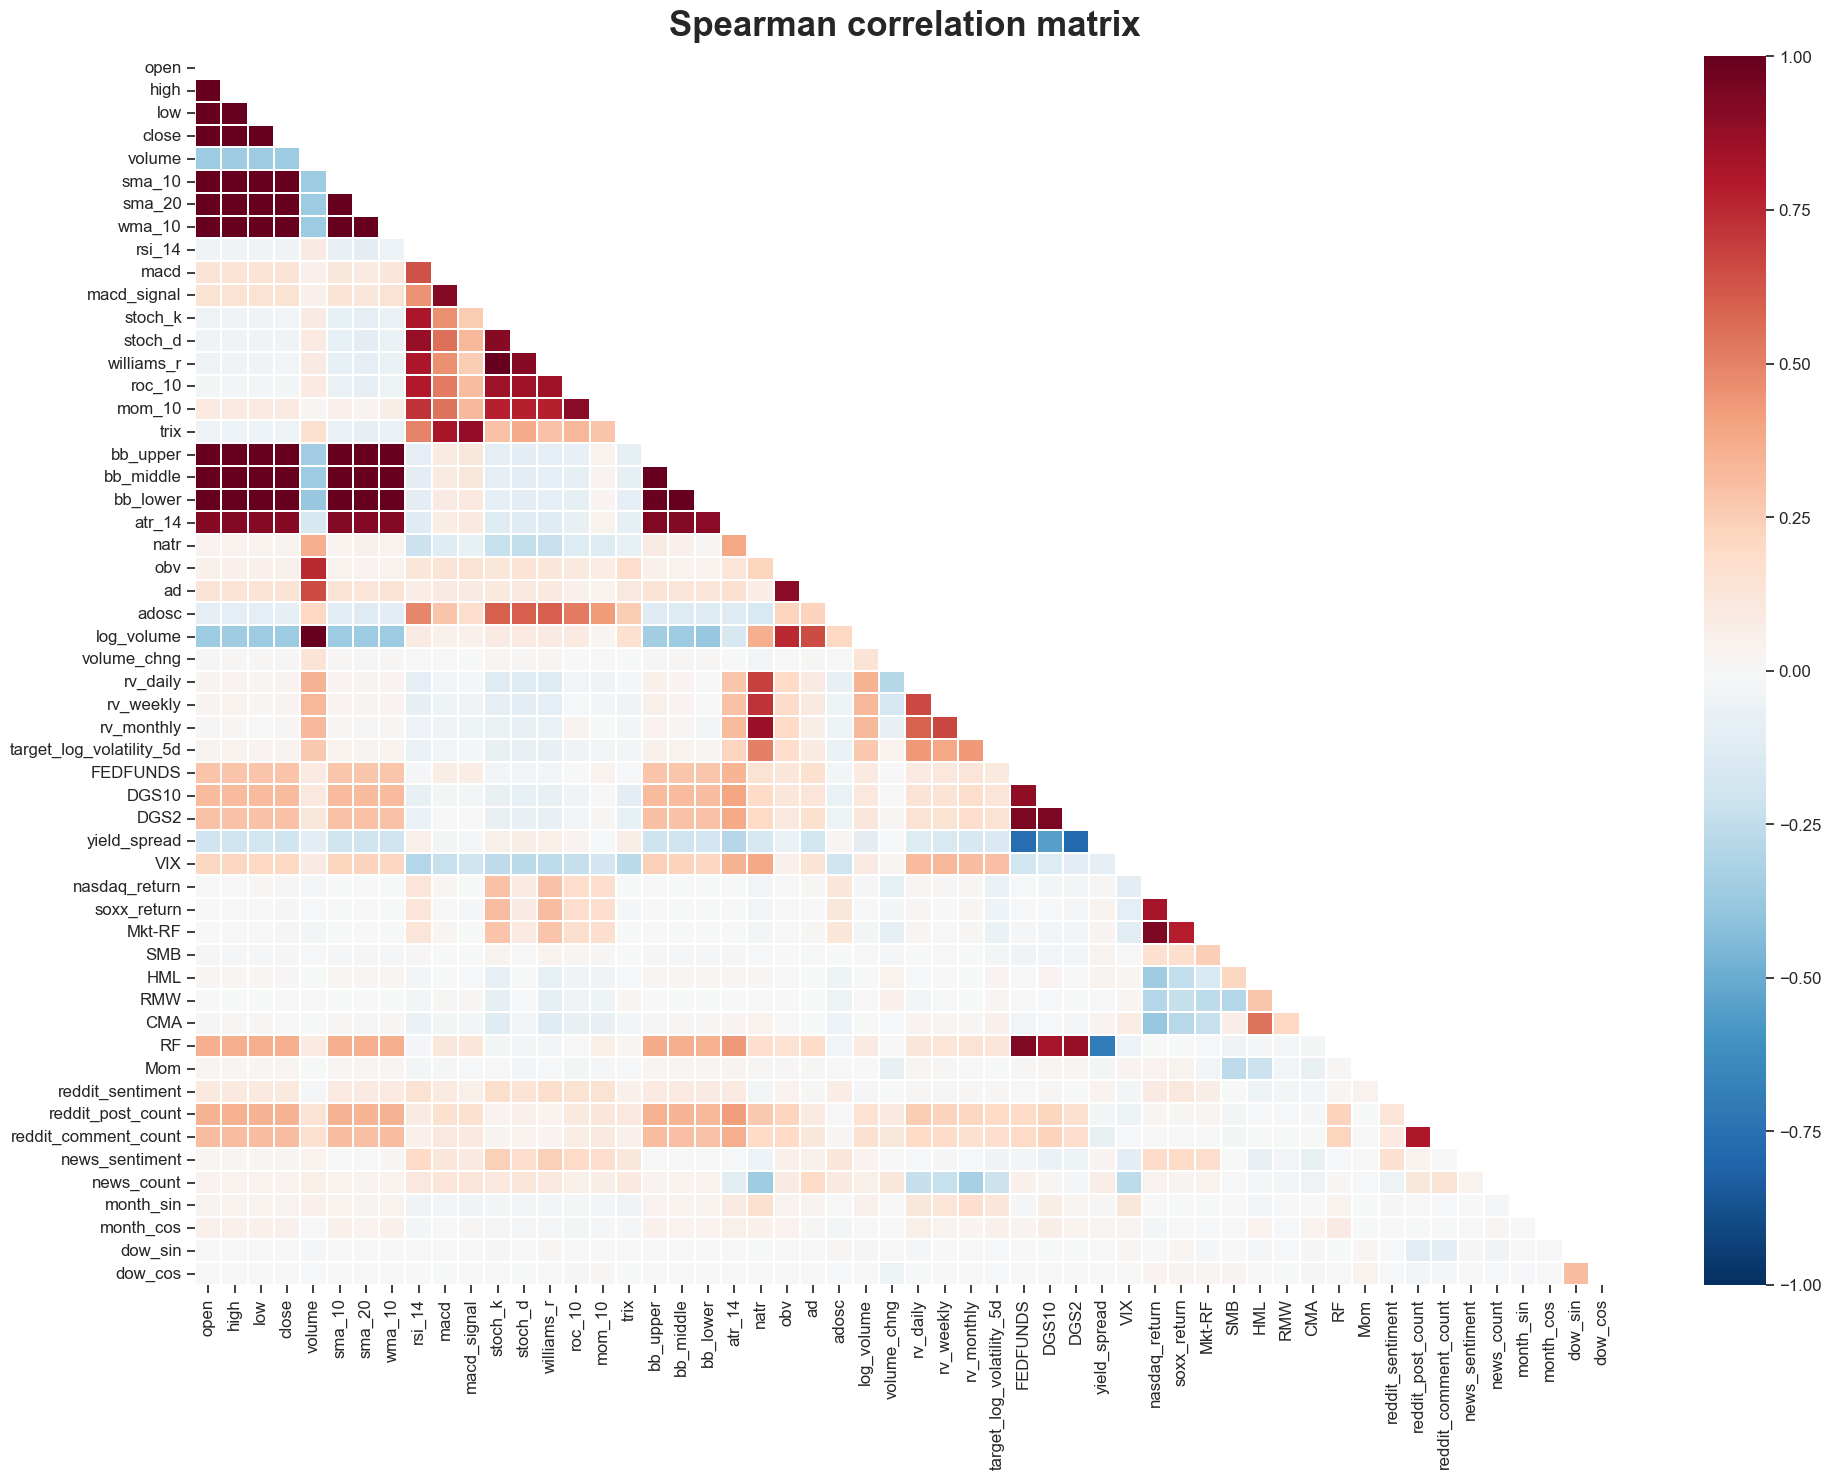

In [11]:
corr_matrix = df[feature_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(20, 15))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    annot=False,
    ax=ax
)

ax.set_title('Spearman correlation matrix',
             fontsize=25, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [19]:
corr_pairs = (
    corr_matrix.abs()
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

high_corr = (
    corr_pairs
    .reset_index()
    .rename(columns={
        'level_0': 'feature_1',
        'level_1': 'feature_2',
        0: 'correlation'
    })
)

pd.set_option('display.max_rows', None)

high_corr[high_corr["correlation"]>0.90]

,feature_1,feature_2,correlation
0,stoch_k,williams_r,1.000000
1,sma_20,bb_middle,1.000000
2,volume,log_volume,1.000000
3,sma_10,wma_10,0.999821
4,low,close,0.999798
5,open,low,0.999797
6,high,close,0.999790
7,open,high,0.999781
8,high,low,0.999696
9,open,close,0.999578


*Several near-perfect correlations were identified among predictors. Most of them arise from indicators that are mathematically related or derived from the same underlying price series. Examples include Stochastic %K and Williams %R, SMA20 and the Bollinger middle band, as well as log returns and one-day percentage returns.*

## 4. Missing values

Missing value imputation is intentionally **not** performed at this stage.
Since imputation strategies must be fit exclusively on the training data
to prevent information leakage from the test set, missing values are
handled later, within the modeling pipelines. The purpose of this section is solely to confirm
the presence and extent of missing data in the final dataset.

In [13]:
missing_summary = (
    df[feature_cols]
    .isna()
    .sum()
    .to_frame('missing_count')
)
missing_summary['missing_pct'] = (
    100 * missing_summary['missing_count'] / len(df)
).round(2)
missing_summary = (
    missing_summary[missing_summary['missing_count'] > 0]
    .sort_values('missing_pct', ascending=False)
)

print(f'Number of features with missing values: {len(missing_summary)} / {len(feature_cols)}')
missing_summary

Number of features with missing values: 5 / 54


,missing_count,missing_pct
reddit_sentiment,1477,19.92
reddit_post_count,1477,19.92
reddit_comment_count,1477,19.92
news_sentiment,916,12.36
news_count,916,12.36


*Missing values occur only in Reddit- and news-derived features, which is expected since some trading days have no relevant posts or news articles. A value of zero naturally represents the absence of activity (no posts, comments, or news) and corresponds to a neutral sentiment signal, so we will use it in preprocesing step of model pipeline.*

## 5. Outlier analysis

Outliers were examined to assess their prevalence and relevance, rather
than to remove them. In financial time series, extreme values (e.g. large
single-day returns, volatility spikes) are typically not measurement
errors but genuine market events - earnings surprises, macroeconomic
announcements, or periods of heightened uncertainty. Removing them would
discard economically meaningful signal rather than noise.

In [15]:
def iqr_outlier_share(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return ((series < lower) | (series > upper)).mean()

outlier_summary = (
    pd.Series(
        {col: iqr_outlier_share(df[col].dropna()) for col in feature_cols},
        name='outlier_share'
    )
    .sort_values(ascending=False)
    .to_frame()
)
outlier_summary['outlier_pct'] = (100 * outlier_summary['outlier_share']).round(2)

outlier_summary.head(15)


,outlier_share,outlier_pct
adosc,0.196412,19.64
macd_signal,0.175907,17.59
mom_10,0.174423,17.44
macd,0.173884,17.39
reddit_sentiment,0.115229,11.52
reddit_comment_count,0.115061,11.51
news_sentiment,0.104972,10.50
Mkt-RF,0.070417,7.04
bb_lower,0.066235,6.62
reddit_post_count,0.065869,6.59


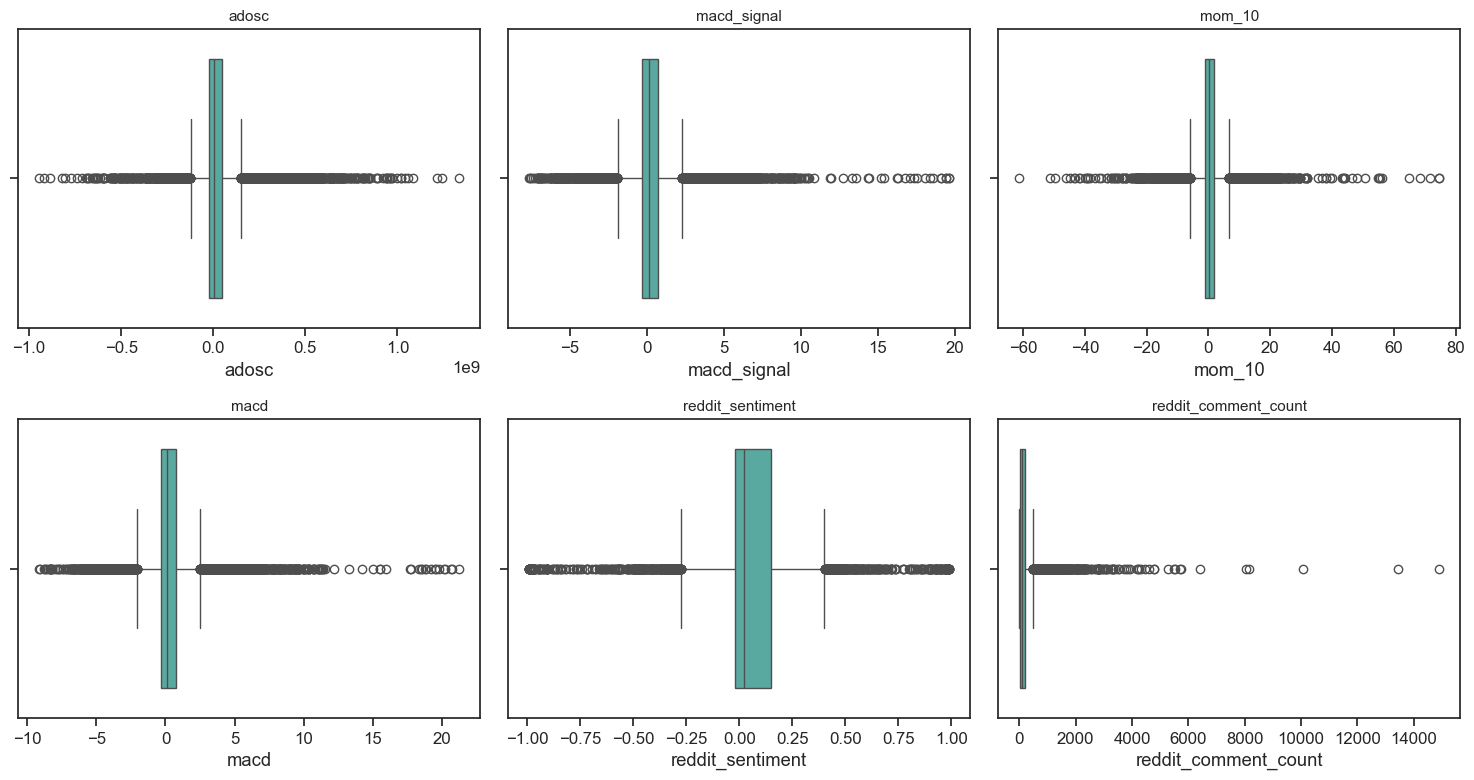

In [16]:
top_outlier_features = outlier_summary.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, top_outlier_features):
    sns.boxplot(x=df[col], ax=ax, color='#4DB6AC')
    ax.set_title(col, fontsize=11)
plt.tight_layout()
plt.show()

*Boxplot analysis indicates the presence of outliers across several predictors, particularly among technical indicators, momentum measures, and sentiment-related variables. Such observations are expected in financial time series, where periods of elevated market volatility, sudden price movements, or unusually high investor attention naturally generate extreme values.*

*Reddit-derived features, especially reddit_comment_count, exhibit a pronounced right-skewed distribution with several extreme observations. These correspond to days when individual posts attracted exceptionally high user engagement, reflecting genuine periods of increased public attention rather than erroneous measurements.*

*No outlier removal was performed. Since these observations represent real market events rather than data quality issues, removing them could eliminate valuable information. Instead, model-specific preprocessing is used in subsequent stages. Logistic Regression employs RobustScaler, which is less sensitive to extreme values, while XGBoost is inherently robust to outliers due to its tree-based learning mechanism.*

In [17]:
df.to_csv('datasets/final/initial_processed_dataset.csv', index=False)

In [18]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("feature_preprocessing")

with mlflow.start_run(run_name="initial_feature_preprocessing"):

    mlflow.log_param("final_feature_count", len(feature_cols))
    mlflow.log_metric(
        "num_high_corr_pairs",
        len(high_corr[high_corr["correlation"] > 0.95])
    )


    print("Run successfully logged.")

Run successfully logged.
